In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay, f1_score)
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

from wordcloud import WordCloud

for pkg in ['stopwords', 'wordnet', 'punkt', 'punkt_tab', 'omw-1.4']:
    nltk.download(pkg, quiet=True)

print('All libraries loaded successfully!')

All libraries loaded successfully!


In [ ]:
# Upload 'Restaurant_Reviews.tsv' via the Files panel on the left in Colab
df = pd.read_csv('/content/Restaurant_Reviews.tsv', sep='\t')

print('Dataset Shape:', df.shape)
print('Columns:', df.columns.tolist())
print('Data Types:')
print(df.dtypes)
print('\nFirst 10 Rows:')
df.head(10)

Dataset Shape: (1000, 2)
Columns: ['Review', 'Liked']
Data Types:
Review    object
Liked      int64
dtype: object

First 10 Rows:


,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1
5,Now I am getting angry and I want my damn pho.,0
6,Honeslty it didn't taste THAT fresh.),0
7,The potatoes were like rubber and you could te...,0
8,The fries were great too.,1
9,A great touch.,1


In [ ]:
print('Target Class Distribution:')
print(df['Liked'].value_counts())
print('\nMissing Values:')
print(df.isnull().sum())

df['review_length'] = df['Review'].apply(len)
df['word_count']    = df['Review'].apply(lambda x: len(x.split()))
print('\nReview Length Stats:')
print(df[['review_length', 'word_count']].describe().round(2))

Target Class Distribution:
Liked
1    500
0    500
Name: count, dtype: int64

Missing Values:
Review    0
Liked     0
dtype: int64

Review Length Stats:
       review_length  word_count
count        1000.00     1000.00
mean           58.32       10.89
std            32.36        6.26
min            11.00        1.00
25%            33.00        6.00
50%            51.00       10.00
75%            80.00       15.00
max           149.00       32.00


In [ ]:
lemmatizer = WordNetLemmatizer()

NEGATIONS = {'not', 'no', 'never', 'nor', 'neither', 'nobody',
             'nothing', 'nowhere', 'cannot', "can't", "won't",
             "doesn't", "didn't", "isn't", "aren't", "wasn't"}

stop_words = set(stopwords.words('english')) - NEGATIONS

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s']", ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(w) for w in tokens
              if w not in stop_words or w in NEGATIONS]
    return ' '.join(tokens)

df['cleaned_review'] = df['Review'].apply(clean_text)

print('Preprocessing complete!')
print('\nBefore vs After (3 examples):')
for i in range(3):
    print(f"  RAW  : {df['Review'].iloc[i]}")
    print(f"  CLEAN: {df['cleaned_review'].iloc[i]}")
    print()

Preprocessing complete!

Before vs After (3 examples):
  RAW  : Wow... Loved this place.
  CLEAN: wow loved place

  RAW  : Crust is not good.
  CLEAN: crust not good

  RAW  : Not tasty and the texture was just nasty.
  CLEAN: not tasty texture nasty



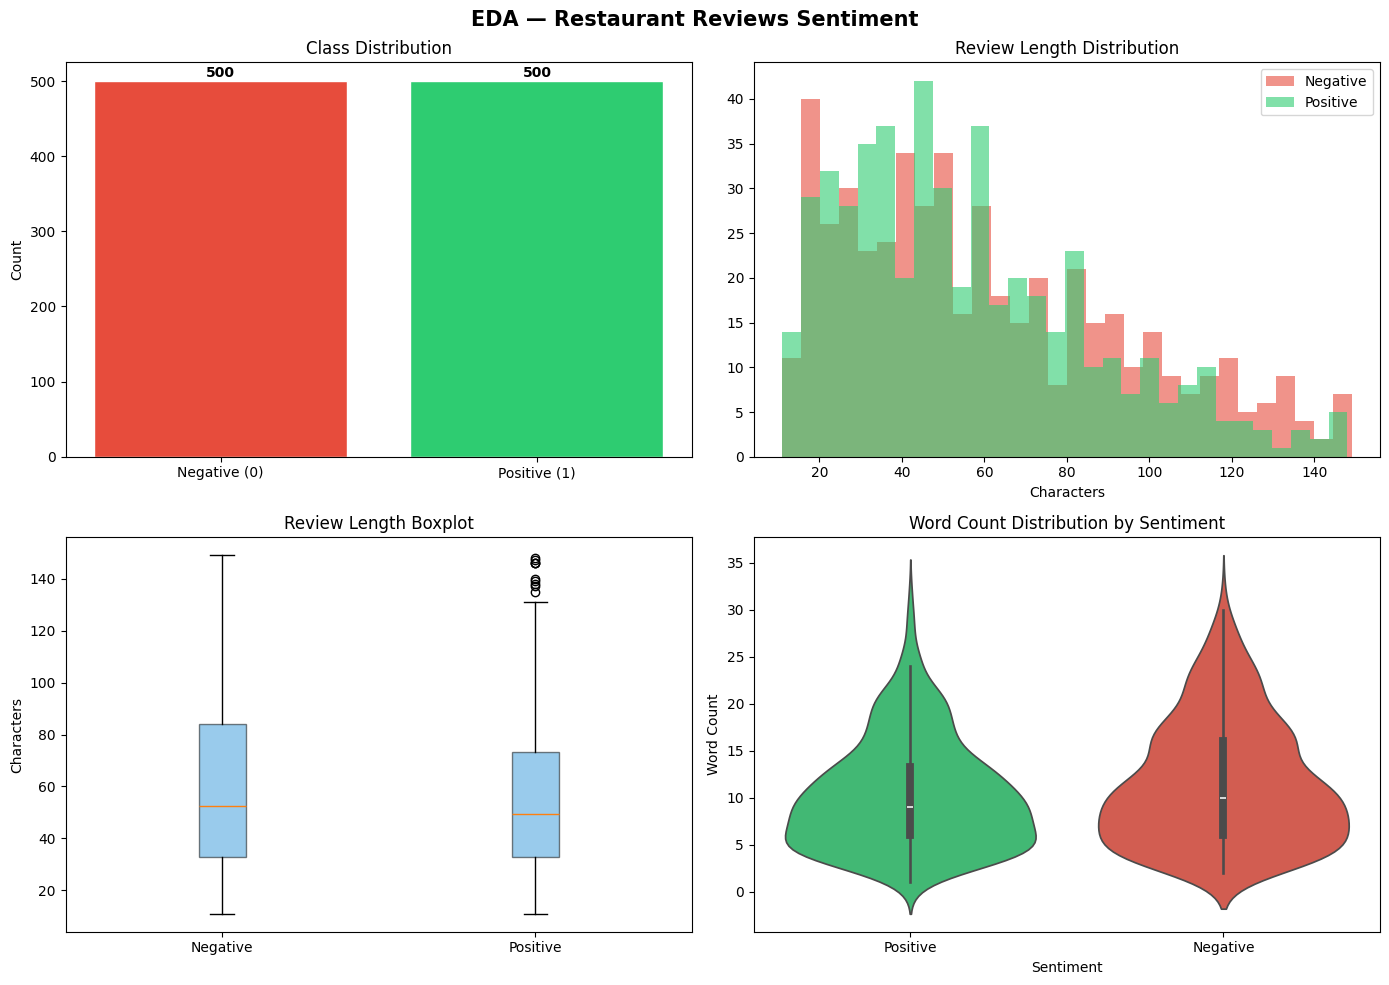

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EDA — Restaurant Reviews Sentiment', fontsize=15, fontweight='bold')

# 1. Class Distribution
counts = df['Liked'].value_counts()
axes[0, 0].bar(['Negative (0)', 'Positive (1)'], counts.values,
               color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[0, 0].set_title('Class Distribution')
axes[0, 0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0, 0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# 2. Review Length by Sentiment
pos = df[df['Liked'] == 1]['review_length']
neg = df[df['Liked'] == 0]['review_length']
axes[0, 1].hist(neg, bins=30, alpha=0.6, color='#e74c3c', label='Negative')
axes[0, 1].hist(pos, bins=30, alpha=0.6, color='#2ecc71', label='Positive')
axes[0, 1].set_title('Review Length Distribution')
axes[0, 1].set_xlabel('Characters')
axes[0, 1].legend()

# 3. Boxplot
axes[1, 0].boxplot([neg, pos], labels=['Negative', 'Positive'],
                   patch_artist=True, boxprops=dict(facecolor='#3498db', alpha=0.5))
axes[1, 0].set_title('Review Length Boxplot')
axes[1, 0].set_ylabel('Characters')

# 4. Violin
plot_data = pd.DataFrame({
    'Word Count': df['word_count'],
    'Sentiment' : df['Liked'].map({1: 'Positive', 0: 'Negative'})
})
sns.violinplot(data=plot_data, x='Sentiment', y='Word Count',
               palette={'Positive': '#2ecc71', 'Negative': '#e74c3c'}, ax=axes[1, 1])
axes[1, 1].set_title('Word Count Distribution by Sentiment')

plt.tight_layout()
plt.show()

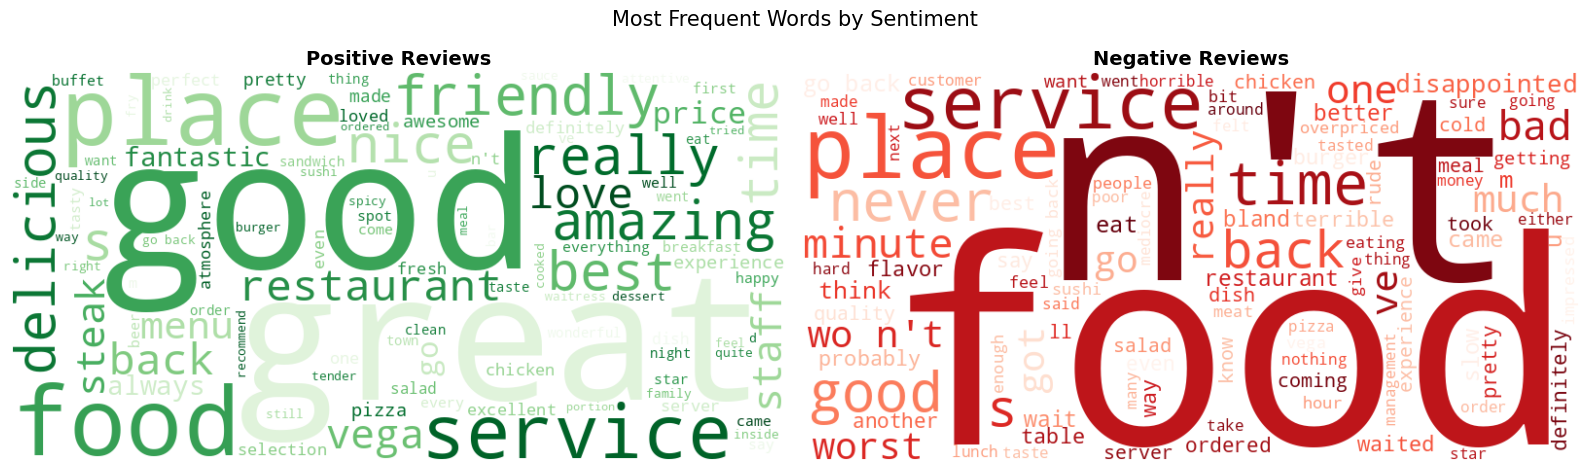

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, label, title, color in zip(
    axes,
    [1, 0],
    ['Positive Reviews', 'Negative Reviews'],
    ['Greens', 'Reds']
):
    text = ' '.join(df[df['Liked'] == label]['cleaned_review'])
    wc = WordCloud(width=800, height=400, background_color='white',
                   colormap=color, max_words=100).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=14, fontweight='bold')

plt.suptitle('Most Frequent Words by Sentiment', fontsize=15)
plt.tight_layout()
plt.show()

In [ ]:
X = df['cleaned_review']
y = df['Liked']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train size : {len(X_train)} samples')
print(f'Test size  : {len(X_test)} samples')
print(f'Train balance: {y_train.value_counts().to_dict()}')
print(f'Test balance : {y_test.value_counts().to_dict()}')

tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=5000,
                        sublinear_tf=True, min_df=2)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'\nTF-IDF Matrix shape (train): {X_train_tfidf.shape}')
print(f'TF-IDF Matrix shape (test) : {X_test_tfidf.shape}')

Train size : 800 samples
Test size  : 200 samples
Train balance: {1: 400, 0: 400}
Test balance : {1: 100, 0: 100}

TF-IDF Matrix shape (train): (800, 822)
TF-IDF Matrix shape (test) : (200, 822)


In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes'        : MultinomialNB(alpha=0.5),
    'Linear SVC'         : LinearSVC(max_iter=2000, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=200, random_state=42),
}

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Training all models with 5-fold cross-validation...\n')
print(f'{"Model":<25} {"CV Acc (mean)":>15} {"CV Acc (std)":>14} {"Test Acc":>10}')
print('-' * 68)

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_tfidf, y_train, cv=cv, scoring='accuracy')
    model.fit(X_train_tfidf, y_train)
    y_pred   = model.predict(X_test_tfidf)
    test_acc = accuracy_score(y_test, y_pred)
    f1       = f1_score(y_test, y_pred, average='weighted')

    results[name] = {
        'model'   : model,
        'cv_mean' : cv_scores.mean(),
        'cv_std'  : cv_scores.std(),
        'test_acc': test_acc,
        'f1'      : f1,
        'y_pred'  : y_pred,
    }
    print(f'{name:<25} {cv_scores.mean():>14.4f} {cv_scores.std():>14.4f} {test_acc:>10.4f}')

print('\nAll models trained!')

Training all models with 5-fold cross-validation...

Model                       CV Acc (mean)   CV Acc (std)   Test Acc
--------------------------------------------------------------------
Logistic Regression               0.7987         0.0260     0.8000
Naive Bayes                       0.7988         0.0354     0.7500
Linear SVC                        0.7900         0.0222     0.7750
Decision Tree                     0.7475         0.0308     0.7400
Random Forest                     0.7737         0.0145     0.7750
Gradient Boosting                 0.7637         0.0251     0.7850

All models trained!


In [ ]:
for name, res in results.items():
    print('=' * 55)
    print(f'  {name}')
    print('=' * 55)
    print(classification_report(y_test, res['y_pred'],
                                target_names=['Negative', 'Positive']))
    print()

  Logistic Regression
              precision    recall  f1-score   support

    Negative       0.81      0.79      0.80       100
    Positive       0.79      0.81      0.80       100

    accuracy                           0.80       200
   macro avg       0.80      0.80      0.80       200
weighted avg       0.80      0.80      0.80       200


  Naive Bayes
              precision    recall  f1-score   support

    Negative       0.76      0.73      0.74       100
    Positive       0.74      0.77      0.75       100

    accuracy                           0.75       200
   macro avg       0.75      0.75      0.75       200
weighted avg       0.75      0.75      0.75       200


  Linear SVC
              precision    recall  f1-score   support

    Negative       0.82      0.71      0.76       100
    Positive       0.74      0.84      0.79       100

    accuracy                           0.78       200
   macro avg       0.78      0.77      0.77       200
weighted avg       0.78

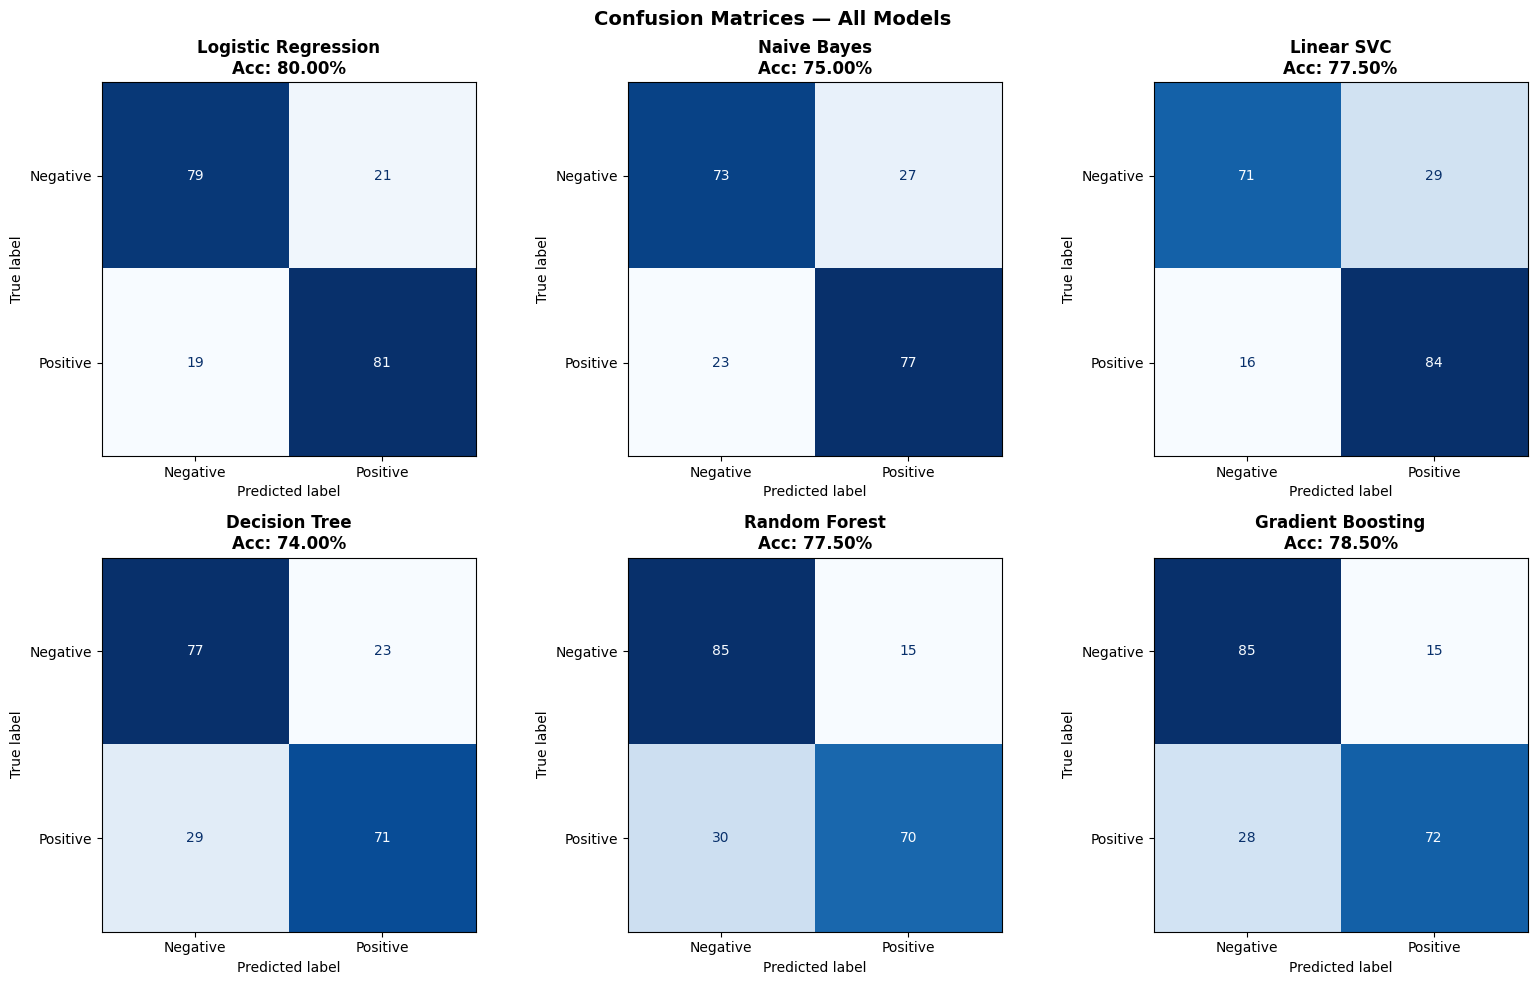

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Positive'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAcc: {res["test_acc"]:.2%}', fontweight='bold')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

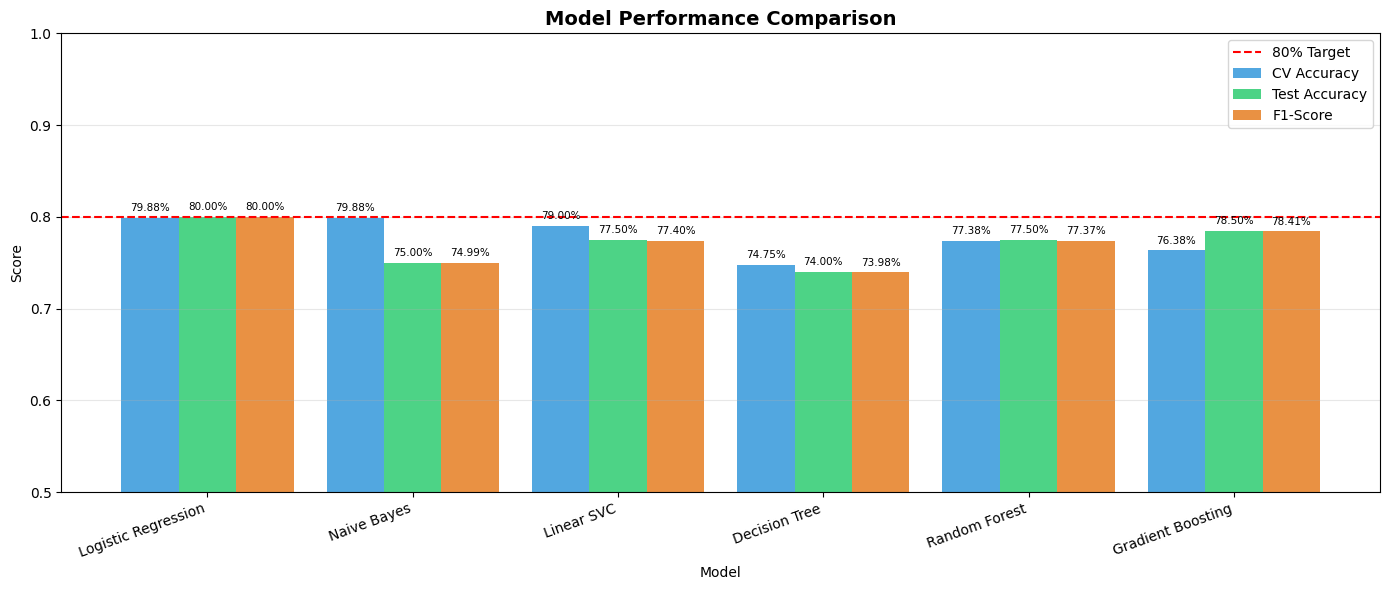

In [ ]:
names     = list(results.keys())
cv_means  = [results[n]['cv_mean']  for n in names]
test_accs = [results[n]['test_acc'] for n in names]
f1_scores = [results[n]['f1']       for n in names]

x     = np.arange(len(names))
width = 0.28

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width, cv_means,  width, label='CV Accuracy',  color='#3498db', alpha=0.85)
bars2 = ax.bar(x,         test_accs, width, label='Test Accuracy', color='#2ecc71', alpha=0.85)
bars3 = ax.bar(x + width, f1_scores, width, label='F1-Score',      color='#e67e22', alpha=0.85)

ax.axhline(0.80, color='red', linestyle='--', linewidth=1.5, label='80% Target')
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=20, ha='right')
ax.set_ylim(0.5, 1.0)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                f'{h:.2%}', ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
plt.show()

In [ ]:
pipe_lr = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True)),
    ('clf',   LogisticRegression(max_iter=1000, random_state=42))
])

param_grid_lr = {
    'tfidf__ngram_range' : [(1, 1), (1, 2), (1, 3)],
    'tfidf__max_features': [3000, 5000, 8000],
    'tfidf__min_df'      : [1, 2],
    'clf__C'             : [0.1, 0.5, 1, 5, 10],
    'clf__solver'        : ['lbfgs', 'liblinear'],
}

gs_lr = GridSearchCV(pipe_lr, param_grid_lr, cv=5,
                     scoring='accuracy', n_jobs=-1, verbose=1)
gs_lr.fit(X_train, y_train)

print(f'\nBest CV Accuracy (LR): {gs_lr.best_score_:.4f}')
print(f'Best Params          : {gs_lr.best_params_}')

Fitting 5 folds for each of 180 candidates, totalling 900 fits

Best CV Accuracy (LR): 0.8337
Best Params          : {'clf__C': 10, 'clf__solver': 'lbfgs', 'tfidf__max_features': 5000, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 3)}


In [ ]:
pipe_svc = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True)),
    ('clf',   LinearSVC(max_iter=2000, random_state=42))
])

param_grid_svc = {
    'tfidf__ngram_range' : [(1, 1), (1, 2)],
    'tfidf__max_features': [5000, 8000],
    'tfidf__min_df'      : [1, 2],
    'clf__C'             : [0.01, 0.1, 0.5, 1, 5],
}

gs_svc = GridSearchCV(pipe_svc, param_grid_svc, cv=5,
                      scoring='accuracy', n_jobs=-1, verbose=1)
gs_svc.fit(X_train, y_train)

print(f'\nBest CV Accuracy (SVC): {gs_svc.best_score_:.4f}')
print(f'Best Params           : {gs_svc.best_params_}')

Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best CV Accuracy (SVC): 0.8313
Best Params           : {'clf__C': 0.5, 'tfidf__max_features': 5000, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2)}


In [ ]:
tuned_models = {
    'Tuned Logistic Regression': gs_lr,
    'Tuned Linear SVC'         : gs_svc,
}

print(f'{"Model":<30} {"Test Accuracy":>14} {"F1-Score":>10}')
print('-' * 58)

for name, gs in tuned_models.items():
    y_pred = gs.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)
    f1     = f1_score(y_test, y_pred, average='weighted')
    print(f'{name:<30} {acc:>14.4f} {f1:>10.4f}')
    print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Model                           Test Accuracy   F1-Score
----------------------------------------------------------
Tuned Logistic Regression              0.8150     0.8148
              precision    recall  f1-score   support

    Negative       0.84      0.78      0.81       100
    Positive       0.79      0.85      0.82       100

    accuracy                           0.81       200
   macro avg       0.82      0.81      0.81       200
weighted avg       0.82      0.81      0.81       200

Tuned Linear SVC                       0.8050     0.8048
              precision    recall  f1-score   support

    Negative       0.83      0.77      0.80       100
    Positive       0.79      0.84      0.81       100

    accuracy                           0.81       200
   macro avg       0.81      0.80      0.80       200
weighted avg       0.81      0.81      0.80       200



Best Model    : Tuned Logistic Regression
Test Accuracy : 0.8150 (81.50%)
Best Params   : {'clf__C': 10, 'clf__solver': 'lbfgs', 'tfidf__max_features': 5000, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 3)}
Meets 80% target: YES


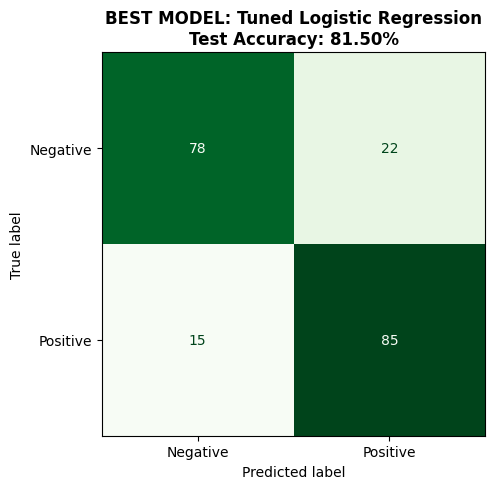

In [ ]:
best_name, best_gs, best_acc = '', None, 0

for name, gs in tuned_models.items():
    acc = accuracy_score(y_test, gs.predict(X_test))
    if acc > best_acc:
        best_acc, best_name, best_gs = acc, name, gs

print(f'Best Model    : {best_name}')
print(f'Test Accuracy : {best_acc:.4f} ({best_acc:.2%})')
print(f'Best Params   : {best_gs.best_params_}')
print(f'Meets 80% target: {"YES" if best_acc >= 0.80 else "NO"}')

y_final = best_gs.predict(X_test)
cm_final = confusion_matrix(y_test, y_final)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(cm_final, display_labels=['Negative', 'Positive'])
disp.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title(f'BEST MODEL: {best_name}\nTest Accuracy: {best_acc:.2%}', fontweight='bold')
plt.tight_layout()
plt.show()

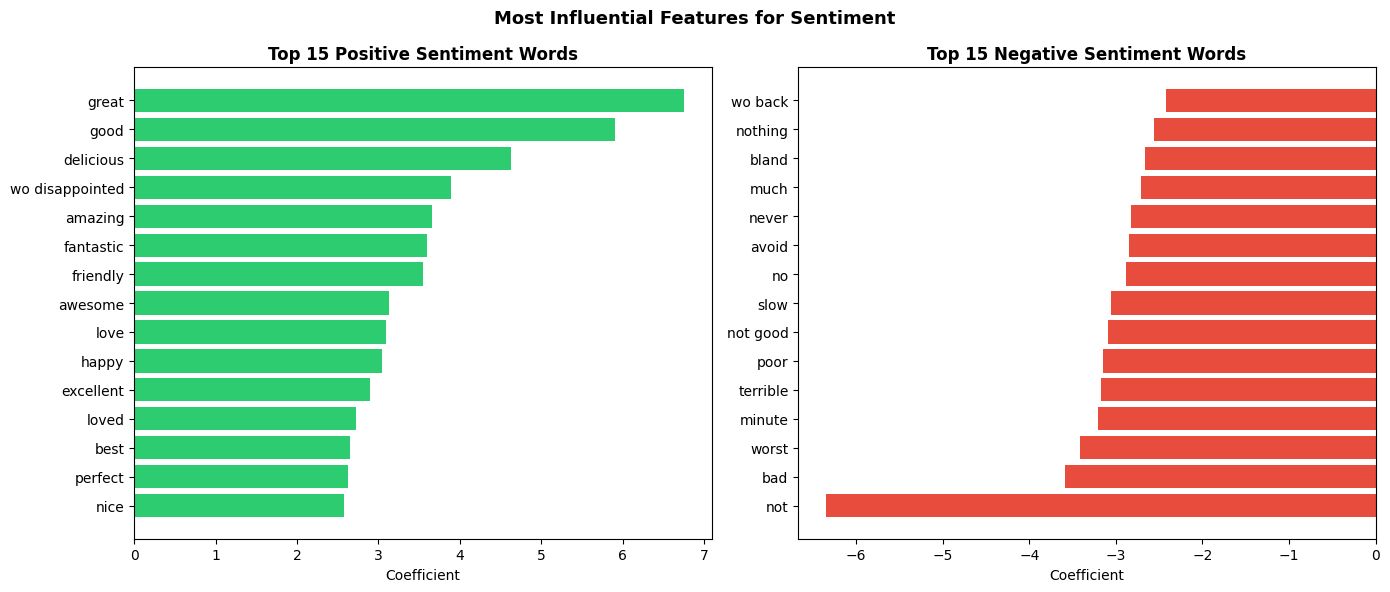

In [ ]:
# Show the top most influential words (works for Logistic Regression)
final_pipeline = best_gs.best_estimator_
vectorizer     = final_pipeline.named_steps['tfidf']
classifier     = final_pipeline.named_steps['clf']

if hasattr(classifier, 'coef_'):
    feature_names = vectorizer.get_feature_names_out()
    coefs = classifier.coef_.flatten()

    top_n = 15
    top_pos_idx = coefs.argsort()[-top_n:][::-1]
    top_neg_idx = coefs.argsort()[:top_n]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    axes[0].barh(feature_names[top_pos_idx][::-1], coefs[top_pos_idx][::-1], color='#2ecc71')
    axes[0].set_title('Top 15 Positive Sentiment Words', fontweight='bold')
    axes[0].set_xlabel('Coefficient')

    axes[1].barh(feature_names[top_neg_idx], coefs[top_neg_idx], color='#e74c3c')
    axes[1].set_title('Top 15 Negative Sentiment Words', fontweight='bold')
    axes[1].set_xlabel('Coefficient')

    plt.suptitle('Most Influential Features for Sentiment', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()



In [ ]:
summary_data = []
for name, res in results.items():
    summary_data.append({
        'Model'    : name,
        'CV Acc'   : f"{res['cv_mean']:.2%}",
        'Test Acc' : f"{res['test_acc']:.2%}",
        'F1-Score' : f"{res['f1']:.2%}",
        'Meets 80%': 'YES' if res['test_acc'] >= 0.80 else 'NO',
    })

for name, gs in tuned_models.items():
    y_p = gs.predict(X_test)
    acc = accuracy_score(y_test, y_p)
    f1  = f1_score(y_test, y_p, average='weighted')
    summary_data.append({
        'Model'    : f'[TUNED] {name}',
        'CV Acc'   : f"{gs.best_score_:.2%}",
        'Test Acc' : f"{acc:.2%}",
        'F1-Score' : f"{f1:.2%}",
        'Meets 80%': 'YES' if acc >= 0.80 else 'NO',
    })

summary_df = pd.DataFrame(summary_data)
print('Final Model Comparison Summary')
print(summary_df.to_string(index=False))

Final Model Comparison Summary
                            Model CV Acc Test Acc F1-Score Meets 80%
              Logistic Regression 79.88%   80.00%   80.00%       YES
                      Naive Bayes 79.88%   75.00%   74.99%        NO
                       Linear SVC 79.00%   77.50%   77.40%        NO
                    Decision Tree 74.75%   74.00%   73.98%        NO
                    Random Forest 77.38%   77.50%   77.37%        NO
                Gradient Boosting 76.38%   78.50%   78.41%        NO
[TUNED] Tuned Logistic Regression 83.38%   81.50%   81.48%       YES
         [TUNED] Tuned Linear SVC 83.12%   80.50%   80.48%       YES


In [ ]:
# Predict on new custom reviews
def predict_sentiment(review_text, pipeline=best_gs):
    cleaned = clean_text(review_text)
    pred    = pipeline.predict([cleaned])[0]
    return 'POSITIVE' if pred == 1 else 'NEGATIVE'

test_reviews = [
    "The food was absolutely amazing and the service was excellent!",
    "Terrible experience. The food was cold and the staff was rude.",
    "It was okay, nothing special but not bad either.",
    "Best pizza I have ever had in my life!",
    "I would not recommend this place to anyone."
]

print('Predictions on New Reviews')
print('=' * 65)
for review in test_reviews:
    sentiment = predict_sentiment(review)
    print(f'Review   : {review}')
    print(f'Sentiment: {sentiment}')
    print('-' * 65)

Predictions on New Reviews
Review   : The food was absolutely amazing and the service was excellent!
Sentiment: POSITIVE
-----------------------------------------------------------------
Review   : Terrible experience. The food was cold and the staff was rude.
Sentiment: NEGATIVE
-----------------------------------------------------------------
Review   : It was okay, nothing special but not bad either.
Sentiment: NEGATIVE
-----------------------------------------------------------------
Review   : Best pizza I have ever had in my life!
Sentiment: POSITIVE
-----------------------------------------------------------------
Review   : I would not recommend this place to anyone.
Sentiment: NEGATIVE
-----------------------------------------------------------------
